Загрузка данных

In [1]:
import  pandas as pd
import geopandas as gpd

houses = gpd.read_feather("data/buildings.feather")
services = gpd.read_feather("data/services.feather")
houses.set_index("physical_object_id", inplace=True, drop=True)
access_matrix = pd.read_feather("data/access_matrix.feather")

Оптимизация обеспеченности для территории

C:\Users\thebe\AppData\Local\pypoetry\Cache\virtualenvs\sirtep-7KE0Akfq-py3.11\Lib\site-packages\cvxpy\problems\problem.py:167: UserWarning: Objective contains too many subexpressions. Consider vectorizing your CVXPY code to speed up compilation.
  warnings.warn("Objective contains too many subexpressions. "
(CVXPY) Oct 01 03:50:31 PM: Your problem has 13760 variables, 33944 constraints, and 0 parameters.


                                     CVXPY                                     
                                     v1.7.3                                    


(CVXPY) Oct 01 03:50:31 PM: It is compliant with the following grammars: DCP, DQCP
(CVXPY) Oct 01 03:50:31 PM: (If you need to solve this problem multiple times, but with different data, consider using parameters.)
(CVXPY) Oct 01 03:50:31 PM: CVXPY will first compile your problem; then, it will invoke a numerical solver to obtain a solution.
(CVXPY) Oct 01 03:50:31 PM: Your problem is compiled with the CPP canonicalization backend.
(CVXPY) Oct 01 03:50:31 PM: Compiling problem (target solver=HIGHS).
(CVXPY) Oct 01 03:50:31 PM: Reduction chain: FlipObjective -> CvxAttr2Constr -> Qp2SymbolicQp -> QpMatrixStuffing -> HIGHS
(CVXPY) Oct 01 03:50:31 PM: Applying reduction FlipObjective
(CVXPY) Oct 01 03:50:31 PM: Applying reduction CvxAttr2Constr
(CVXPY) Oct 01 03:50:31 PM: Applying reduction Qp2SymbolicQp


-------------------------------------------------------------------------------
                                  Compilation                                  
-------------------------------------------------------------------------------


(CVXPY) Oct 01 03:50:33 PM: Applying reduction QpMatrixStuffing
(CVXPY) Oct 01 03:51:00 PM: Applying reduction HIGHS
(CVXPY) Oct 01 03:51:00 PM: Finished problem compilation (took 2.891e+01 seconds).
(CVXPY) Oct 01 03:51:00 PM: Invoking solver HIGHS  to obtain a solution.


-------------------------------------------------------------------------------
                                Numerical solver                               
-------------------------------------------------------------------------------


(CVXPY) Oct 01 03:51:00 PM: Problem status: optimal
(CVXPY) Oct 01 03:51:00 PM: Optimal value: nan
(CVXPY) Oct 01 03:51:00 PM: Compilation took 2.891e+01 seconds
(CVXPY) Oct 01 03:51:00 PM: Solver (including time spent in interface) took 4.499e-01 seconds


-------------------------------------------------------------------------------
                                    Summary                                    
-------------------------------------------------------------------------------


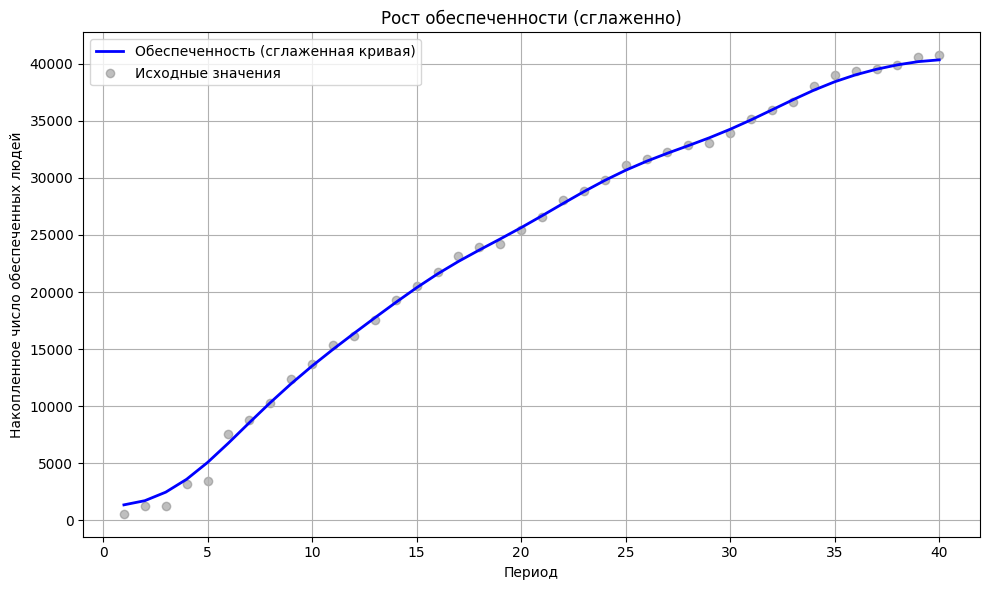

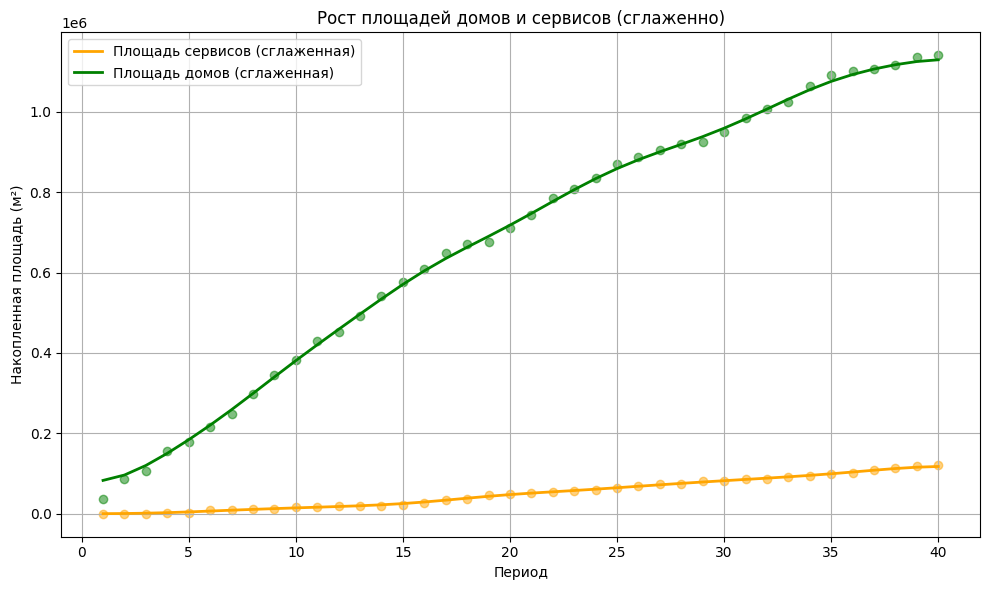

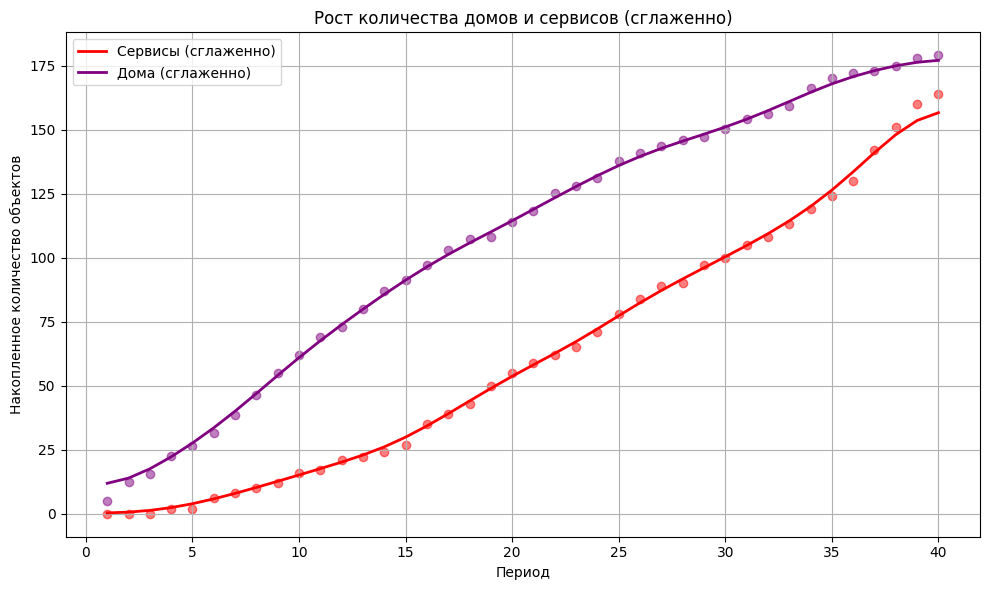

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d

from src.sirtep import optimize_provision_building_schedule

result = optimize_provision_building_schedule(
    houses,
    services,
    access_matrix,
    50000,
    40
)
periods = [i for i in range(1, 41)]
provided_cumulative = np.array(result.provided_per_period)

sigma = 2
smooth_provided = gaussian_filter1d(provided_cumulative, sigma=sigma)

plt.figure(figsize=(10,6))
plt.plot(periods, smooth_provided, label='Обеспеченность (сглаженная кривая)', color='blue', linewidth=2)
plt.scatter(periods, provided_cumulative, color='gray', alpha=0.5, label='Исходные значения')
plt.xlabel('Период')
plt.ylabel('Накопленное число обеспеченных людей')
plt.title('Рост обеспеченности (сглаженно)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

smooth_services_area = gaussian_filter1d(np.cumsum(result.services_area_per_period), sigma=sigma)
smooth_houses_area = gaussian_filter1d(np.cumsum(result.houses_area_per_period), sigma=sigma)

plt.figure(figsize=(10,6))
plt.plot(periods, smooth_services_area, label='Площадь сервисов (сглаженная)', color='orange', linewidth=2)
plt.plot(periods, smooth_houses_area, label='Площадь домов (сглаженная)', color='green', linewidth=2)
plt.scatter(periods, np.cumsum(result.services_area_per_period), color='orange', alpha=0.5)
plt.scatter(periods, np.cumsum(result.houses_area_per_period), color='green', alpha=0.5)
plt.xlabel('Период')
plt.ylabel('Накопленная площадь (м²)')
plt.title('Рост площадей домов и сервисов (сглаженно)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

smooth_services_count = gaussian_filter1d(np.cumsum(result.services_per_period), sigma=sigma)
smooth_houses_count = gaussian_filter1d(np.cumsum(result.houses_per_period), sigma=sigma)

plt.figure(figsize=(10,6))
plt.plot(periods, smooth_services_count, label='Сервисы (сглаженно)', color='red', linewidth=2)
plt.plot(periods, smooth_houses_count, label='Дома (сглаженно)', color='purple', linewidth=2)
plt.scatter(periods, np.cumsum(result.services_per_period), color='red', alpha=0.5)
plt.scatter(periods, np.cumsum(result.houses_per_period), color='purple', alpha=0.5)
plt.xlabel('Период')
plt.ylabel('Накопленное количество объектов')
plt.title('Рост количества домов и сервисов (сглаженно)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

Оптимизация объектов по приоритету

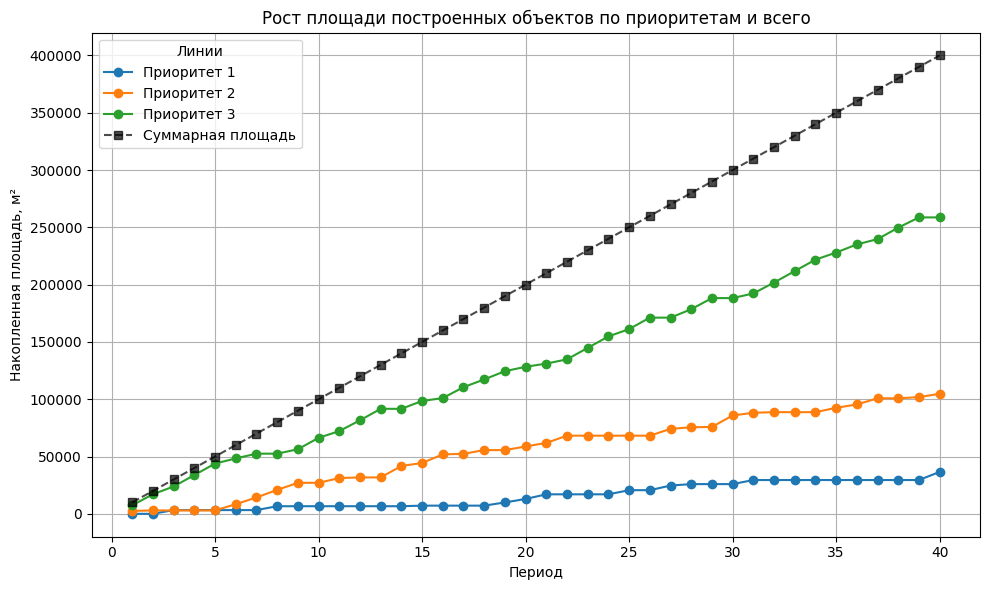

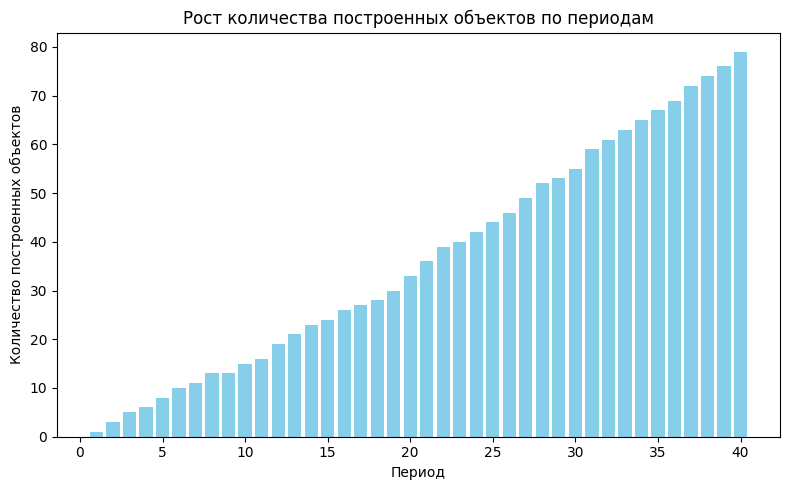

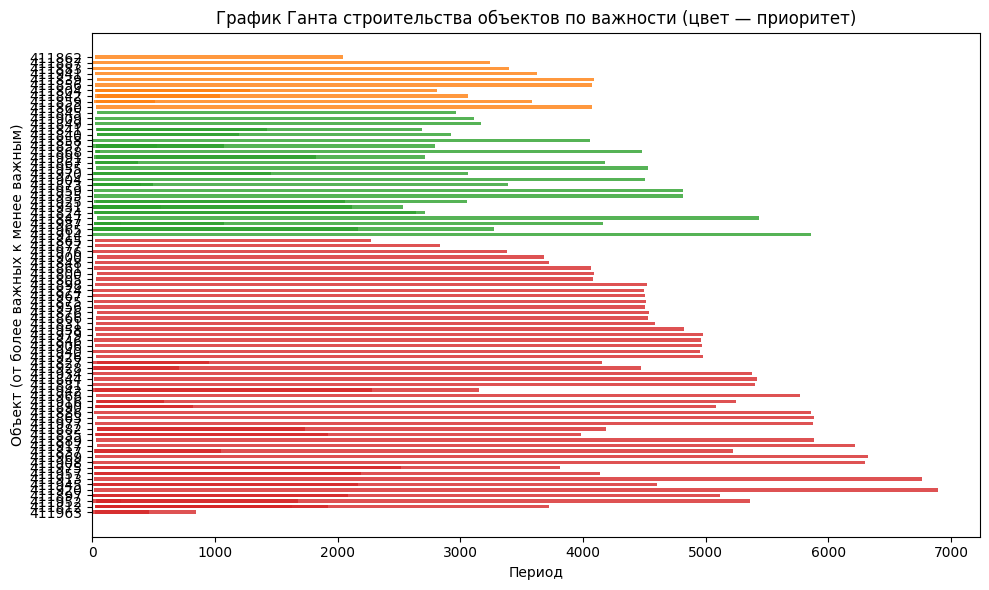

In [3]:
import numpy as np
import matplotlib.pyplot as plt

from sirtep import optimize_building_schedule

houses["area"] = houses["living_area"]
houses["priority"] = np.random.randint(1, 4, size=len(houses))

schedule_df = optimize_building_schedule(houses)

schedule_df["built_area"] = schedule_df["percent_built"] * schedule_df["area"]
max_period = schedule_df['period'].max()
periods = list(range(1, max_period+1))

priorities = sorted(schedule_df['priority'].unique())
area_by_priority = {}
for prio in priorities:
    prio_df = schedule_df[schedule_df["priority"] == prio]
    growth = []
    cum_area = 0.0
    for period in periods:
        built = prio_df[prio_df['period'] == period]
        cum_area += built["built_area"].sum()
        growth.append(cum_area)
    area_by_priority[prio] = growth

total_growth = []
cum_total = 0.0
for period in periods:
    built = schedule_df[schedule_df['period'] == period]
    cum_total += built["built_area"].sum()
    total_growth.append(cum_total)

plt.figure(figsize=(10,6))

for prio in priorities:
    plt.plot(periods, area_by_priority[prio], marker='o', label=f'Приоритет {prio}')

plt.plot(periods, total_growth, marker='s', linestyle='--', label='Суммарная площадь', color='black', alpha=0.7)
plt.xlabel("Период")
plt.ylabel("Накопленная площадь, м²")
plt.title("Рост площади построенных объектов по приоритетам и всего")
plt.legend(title="Линии")
plt.grid()
plt.tight_layout()
plt.show()

total_built = schedule_df.groupby("name")["percent_built"].sum()
built_objects = (total_built >= 1).sum()
periods = schedule_df["period"].max()
built_counts = []
for p in range(1, periods+1):
    sub = schedule_df[schedule_df["period"] <= p]
    total_built = sub.groupby("name")["percent_built"].sum()
    count = (total_built >= 1).sum()
    built_counts.append(count)
plt.figure(figsize=(8,5))
plt.bar(range(1, periods+1), built_counts, color='skyblue')
plt.xlabel("Период")
plt.ylabel("Количество построенных объектов")
plt.title("Рост количества построенных объектов по периодам")
plt.tight_layout()
plt.show()


names_sorted = schedule_df.groupby("name")[["priority", "area"]].first().sort_values(["priority", "area"], ascending=[False, False]).index
plt.figure(figsize=(10, 6))
for i, name in enumerate(names_sorted):
    obj = schedule_df[schedule_df['name'] == name]
    for _, row in obj.iterrows():
        plt.barh(name, row['percent_built'] * row['area'], left=row['period']-1, height=0.6,
                 color=f'C{int(row["priority"])%10}', alpha=0.8)
plt.xlabel("Период")
plt.ylabel("Объект (от более важных к менее важным)")
plt.title("График Ганта строительства объектов по важности (цвет — приоритет)")
plt.tight_layout()
plt.show()